In [1]:
from functions import *
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read the results from the raw file

variables = ['time','v(vout)','v(v8i)','i(vi8xpi)']
resultados = readRaw('../tran_linearity_8xPI_top_pex.raw',variables)

The shortest period was: 1.3749999999951005e-09
The longest period was: 1.3800000000016177e-09
The average period: 1.3764285714285763e-09
The difference corresponds to a phase error of 1.307732227962988


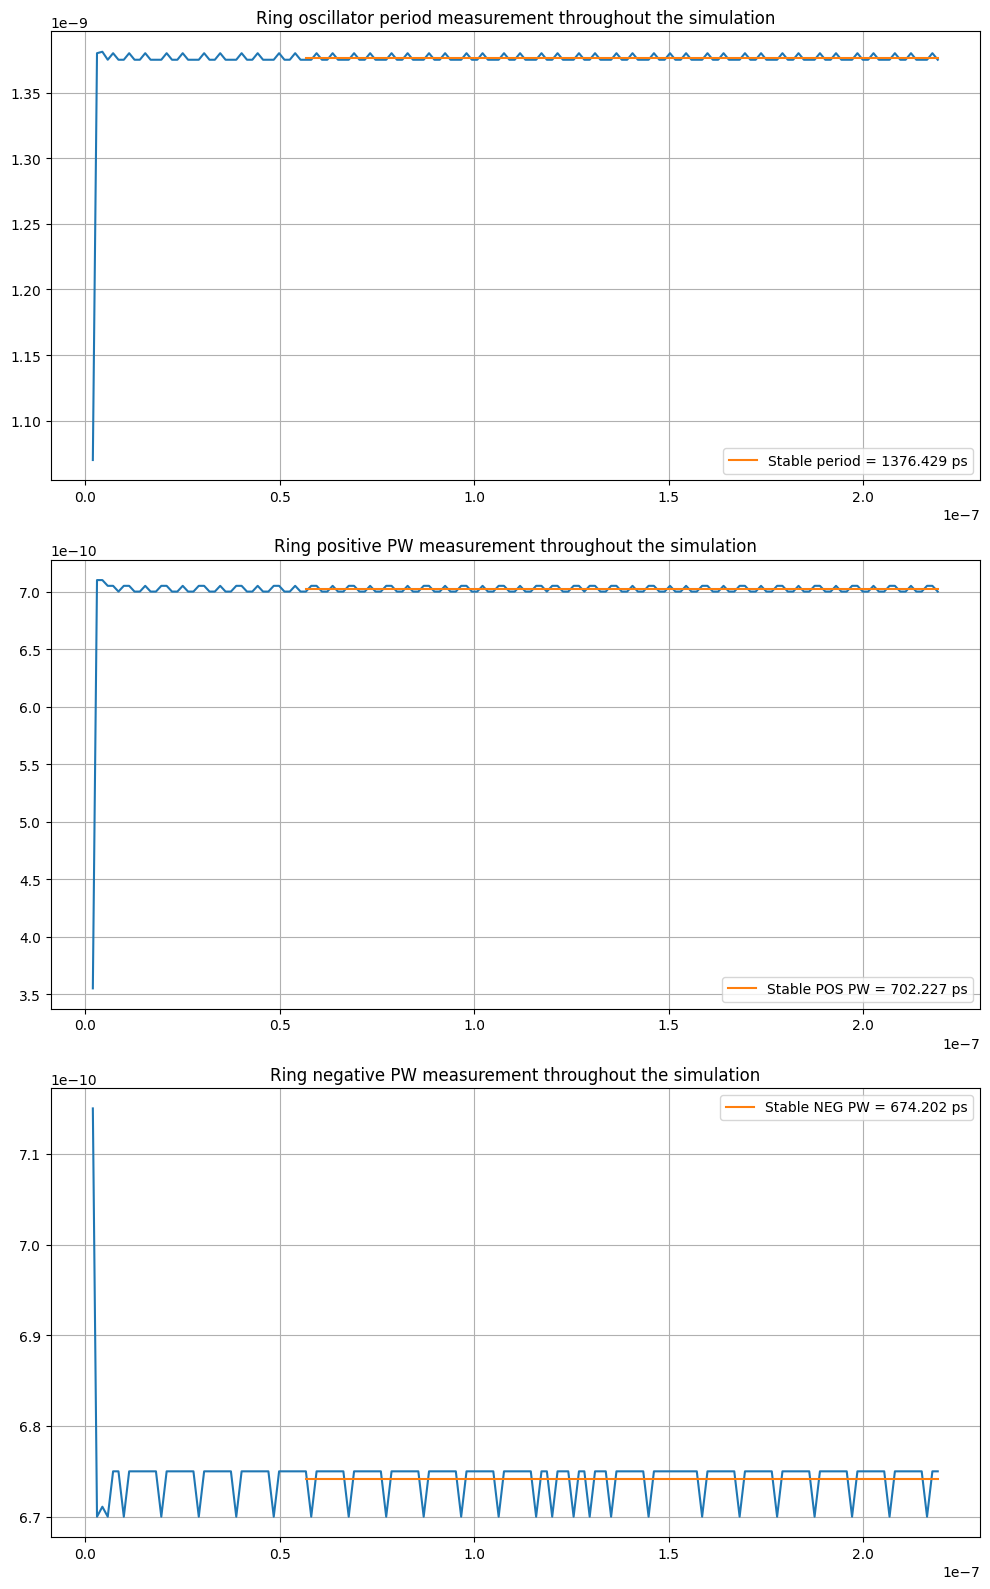

In [3]:
data_ring = meas_period(resultados["v(v8i)"],resultados["time"],0.6)
transient_cycles = 40
stable_period = np.mean(data_ring["meas_period"][transient_cycles:])
min_stable_period = np.min(data_ring["meas_period"][transient_cycles:])
max_stable_period = np.max(data_ring["meas_period"][transient_cycles:])
stable_pos_pw = np.mean(data_ring["pos_pw"][transient_cycles:])
stable_neg_pw = np.mean(data_ring["neg_pw"][transient_cycles:])

fig_ring = plt.figure(figsize=[10,16])
period_ring_ax = fig_ring.add_subplot(3,1,1)
pos_pw_ring_ax = fig_ring.add_subplot(3,1,2)
neg_pw_ring_ax = fig_ring.add_subplot(3,1,3)


period_ring_ax.plot(data_ring["time_meas"][:-1],data_ring["meas_period"])
period_ring_ax.plot(data_ring["time_meas"][transient_cycles:-1],
                    [stable_period]*len(data_ring["time_meas"][transient_cycles:-1]),
                    label=f"Stable period = {np.round(stable_period*1e12,decimals=3)} ps")
period_ring_ax.legend()
period_ring_ax.grid()
period_ring_ax.set_title("Ring oscillator period measurement throughout the simulation")                    

pos_pw_ring_ax.plot(data_ring["time_meas"][:len(data_ring["pos_pw"])],data_ring["pos_pw"])
pos_pw_ring_ax.plot(data_ring["time_meas"][transient_cycles:-1],
                    [stable_pos_pw]*len(data_ring["time_meas"][transient_cycles:-1]),
                    label=f"Stable POS PW = {np.round(stable_pos_pw*1e12,decimals=3)} ps")
pos_pw_ring_ax.legend()
pos_pw_ring_ax.grid()
pos_pw_ring_ax.set_title("Ring positive PW measurement throughout the simulation")                    

neg_pw_ring_ax.plot(data_ring["time_meas"][:-1],data_ring["neg_pw"])
neg_pw_ring_ax.plot(data_ring["time_meas"][transient_cycles:-1],
                    [stable_neg_pw]*len(data_ring["time_meas"][transient_cycles:-1]),
                    label=f"Stable NEG PW = {np.round(stable_neg_pw*1e12,decimals=3)} ps")
neg_pw_ring_ax.legend()
neg_pw_ring_ax.grid()
neg_pw_ring_ax.set_title("Ring negative PW measurement throughout the simulation")

fig_ring.tight_layout()
print(f"The shortest period was: {min_stable_period}")
print(f"The longest period was: {max_stable_period}")
print(f"The average period: {stable_period}")
print(f"The difference corresponds to a phase error of {(max_stable_period-min_stable_period)*360/stable_period}")

In [4]:
### Length of each quadrant
LEN_Q = stable_period*4*8
#stable_period = 1375e-12

### Capture offset
OFFS = stable_period*4*8
offs_time = np.abs(np.array(resultados['time'], dtype=float) - OFFS).argmin()

# First quadrant
len_timeQ1 = np.abs(np.array(resultados['time'], dtype=float) - LEN_Q - OFFS).argmin()
vout_Q1 = resultados['v(vout)'][offs_time:len_timeQ1]
time_Q1 = resultados['time'][offs_time:len_timeQ1]
v8i_Q1 = resultados['v(v8i)'][offs_time:len_timeQ1]
print(time_Q1[0])
print(time_Q1[-1])

# Second quadrant
len_timeQ2 = np.abs(np.array(resultados['time'], dtype=float) - 2*LEN_Q - OFFS).argmin()
vout_Q2 = resultados['v(vout)'][len_timeQ1:len_timeQ2]
v8i_Q2 = resultados['v(v8i)'][len_timeQ1:len_timeQ2]
time_Q2 = resultados['time'][len_timeQ1:len_timeQ2]


# Third quadrant
len_timeQ3 = np.abs(np.array(resultados['time'], dtype=float) - 3*LEN_Q - OFFS).argmin()
vout_Q3 = resultados['v(vout)'][len_timeQ2:len_timeQ3]
v8i_Q3 = resultados['v(v8i)'][len_timeQ2:len_timeQ3]
time_Q3 = resultados['time'][len_timeQ2:len_timeQ3]

# Fourth quadrant
len_timeQ4 = np.abs(np.array(resultados['time'], dtype=float) - 4*LEN_Q - OFFS).argmin()
vout_Q4 = resultados['v(vout)'][len_timeQ3:len_timeQ4]
v8i_Q4 = resultados['v(v8i)'][len_timeQ3:len_timeQ4]
time_Q4 = resultados['time'][len_timeQ3:len_timeQ4]

# Quadrant limits
print(resultados['time'][offs_time])
print(time_Q1[0])
print(time_Q1[-1])
print(time_Q2[0])
print(time_Q2[-1])
print(time_Q3[0])
print(time_Q3[-1])
print(time_Q4[0])
print(time_Q4[-1])

4.404749999999999e-08
8.808750000000621e-08
4.404749999999999e-08
4.404749999999999e-08
8.808750000000621e-08
8.809250000000621e-08
1.321325e-07
1.321375e-07
1.761775e-07
1.761825e-07
2.202235e-07


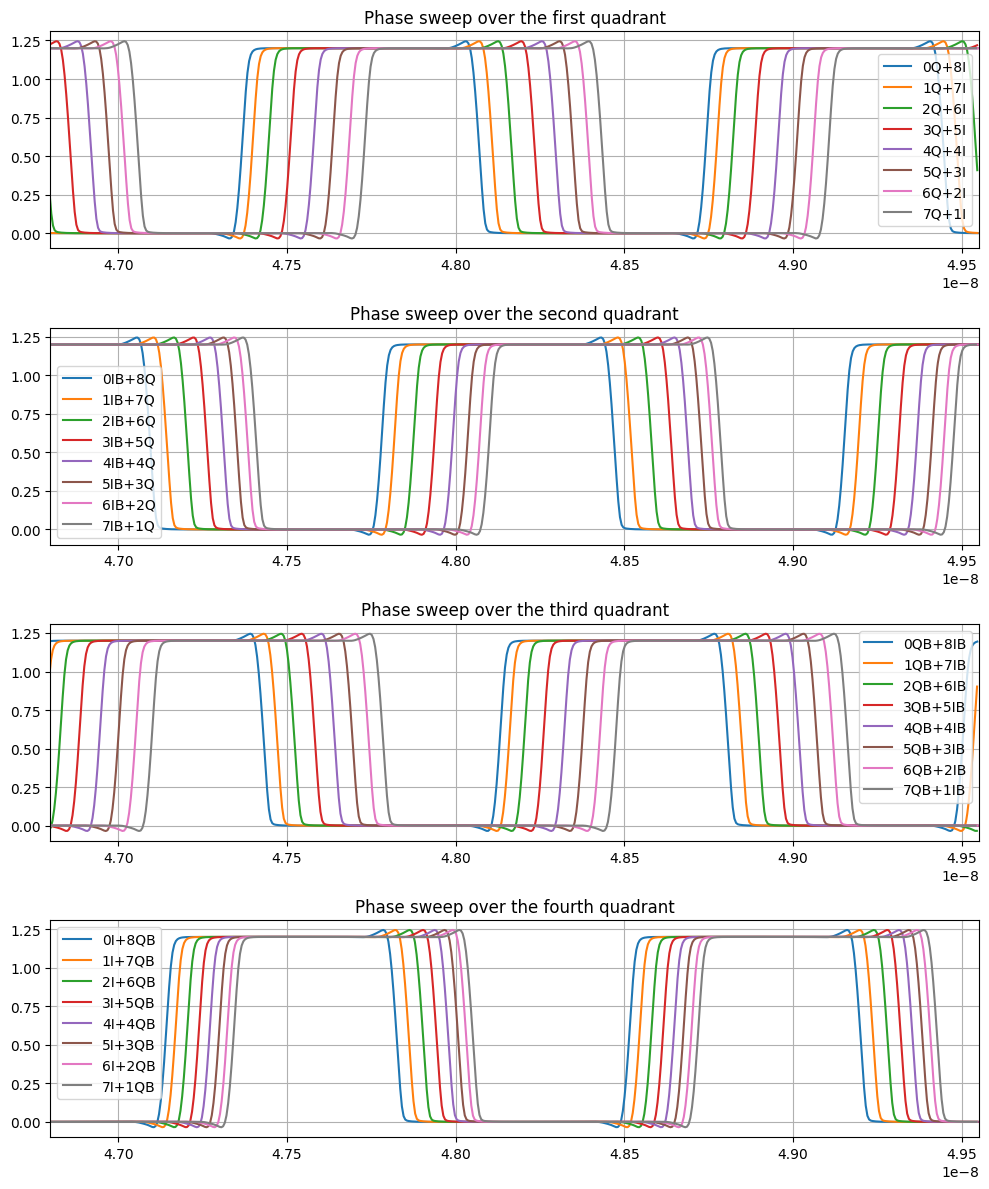

In [5]:
# Graphs window generation
results = plt.figure(figsize=[10,12])
quadrant1 = results.add_subplot(4,1,1)
quadrant2 = results.add_subplot(4,1,2)
quadrant3 = results.add_subplot(4,1,3)
quadrant4 = results.add_subplot(4,1,4)

# Fist quadrant
graph_QUADRv3(vout_Q1,time_Q1,1,stable_period,['Q','I'],quadrant1)
quadrant1.set_xlim(OFFS+stable_period*2, OFFS+stable_period*4)
quadrant1.set_title('Phase sweep over the first quadrant')

# Second quadrant
graph_QUADRv3(vout_Q2,time_Q2,2,stable_period,['IB','Q'],quadrant2)
quadrant2.set_xlim(OFFS+stable_period*2, OFFS+stable_period*4)
quadrant2.set_title('Phase sweep over the second quadrant')

# Third quadrant
graph_QUADRv3(vout_Q3,time_Q3,3,stable_period,['QB','IB'],quadrant3)
quadrant3.set_xlim(OFFS+stable_period*2, OFFS+stable_period*4)
quadrant3.set_title('Phase sweep over the third quadrant')

# Fourth quadrant
graph_QUADRv3(vout_Q4,time_Q4,4,stable_period,['I','QB'],quadrant4)
quadrant4.set_xlim(OFFS+stable_period*2, OFFS+stable_period*4)
quadrant4.set_title('Phase sweep over the fourth quadrant')

results.tight_layout()

In [6]:
offset = phase_measv2(vout_Q1,v8i_Q1,time_Q1,stable_period,0.6,0,1)
print(offset[0])
phase_Q1 = phase_measv2(vout_Q1,v8i_Q1,time_Q1,stable_period,0.6,offset[0],1)
print(phase_Q1)
phase_Q2 = phase_measv2(vout_Q2,v8i_Q2,time_Q2,stable_period,0.6,offset[0],2)
print(phase_Q2)
phase_Q3 = phase_measv2(vout_Q3,v8i_Q3,time_Q3,stable_period,0.6,offset[0],3)
print(phase_Q3)
phase_Q4 = phase_measv2(vout_Q4,v8i_Q4,time_Q4,stable_period,0.6,offset[0],4)
print(phase_Q4)

65.01297353390862
[np.float64(0.0), np.float64(8.22003), np.float64(19.98962), np.float64(36.99014), np.float64(55.29839), np.float64(70.99118), np.float64(84.0685), np.float64(94.53036)]
[np.float64(106.29995), np.float64(118.06954), np.float64(132.45459), np.float64(149.45511), np.float64(163.84017), np.float64(175.60976), np.float64(183.45615), np.float64(191.30254)]
[np.float64(197.8412), np.float64(206.99533), np.float64(218.76492), np.float64(234.45771), np.float64(248.84276), np.float64(263.22782), np.float64(276.30514), np.float64(289.38246)]
[np.float64(300.21796), np.float64(308.06435), np.float64(318.52621), np.float64(326.3726), np.float64(334.21899), np.float64(342.06539), np.float64(348.60405), np.float64(353.83498)]


In [7]:
phase_sweep = list(dict.fromkeys(phase_Q1+phase_Q2+phase_Q3+phase_Q4))
print(len(phase_sweep))

32


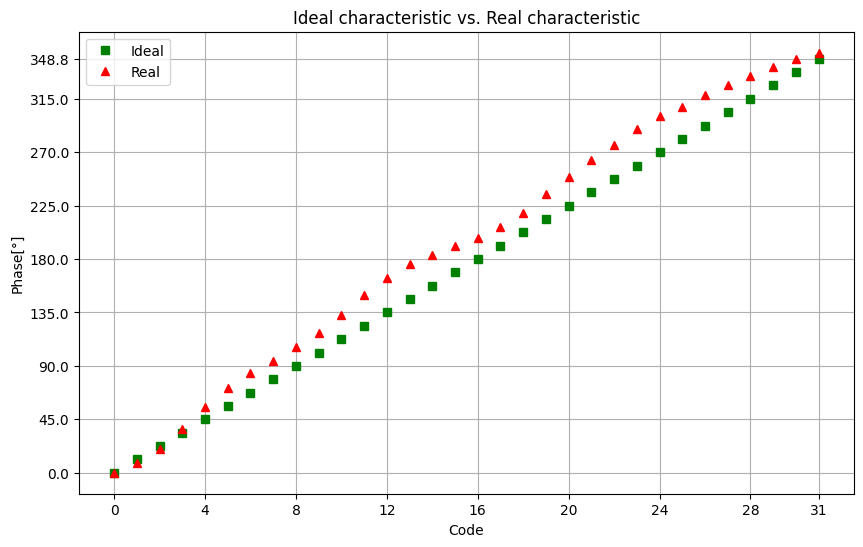

In [8]:
phase_sweep_ideal = np.linspace(0,360,32, endpoint=False)
codigo = np.arange(0,32)

fig_ideal_sweep, ax_ideal_sweep = plt.subplots(figsize=[10,6])
ax_ideal_sweep.plot(codigo,phase_sweep_ideal,'gs',label='Ideal')
ax_ideal_sweep.plot(codigo,phase_sweep,'r^', label='Real')
ax_ideal_sweep.set_xlabel('Code')
ax_ideal_sweep.set_ylabel('Phase[°]')
ax_ideal_sweep.set_title('Ideal characteristic vs. Real characteristic')
ax_ideal_sweep.set_xticks([0,4,8,12,16,20,24,28,31])
ax_ideal_sweep.set_yticks([0,45,90,135,180,225,270,315,348.75])
ax_ideal_sweep.grid()
ax_ideal_sweep.legend()


In [9]:
INL = calc_INL(phase_sweep_ideal,phase_sweep)
print(INL)
DNL = calc_DNL(phase_sweep)
print(DNL)
SKEW = calc_SKEW(np.array(resultados['v(vout)'][offs_time:],dtype=float),np.array(resultados['time'][offs_time:],dtype=float),stable_period,0.6)
print(SKEW)

[np.float64(0.0), np.float64(-0.2693306666666667), np.float64(-0.223144888888889), np.float64(0.2880124444444441), np.float64(0.9154124444444443), np.float64(1.310327111111111), np.float64(1.4727555555555556), np.float64(1.4026986666666668), np.float64(1.448884444444444), np.float64(1.4950702222222225), np.float64(1.773741333333333), np.float64(2.284898666666666), np.float64(2.5635706666666667), np.float64(2.609756444444444), np.float64(2.3072133333333342), np.float64(2.0046702222222215), np.float64(1.5858844444444433), np.float64(1.3995848888888884), np.float64(1.4457706666666656), np.float64(1.8406853333333326), np.float64(2.119356444444444), np.float64(2.3980284444444453), np.float64(2.5604568888888886), np.float64(2.7228853333333314), np.float64(2.6860408888888894), np.float64(2.383497777777777), np.float64(2.313440888888888), np.float64(2.010897777777776), np.float64(1.7083546666666685), np.float64(1.4058124444444426), np.float64(0.9870266666666642), np.float64(0.45199822222221986

Max. DNL:  0.6274000000000001
Max. INL:  2.7228853333333314


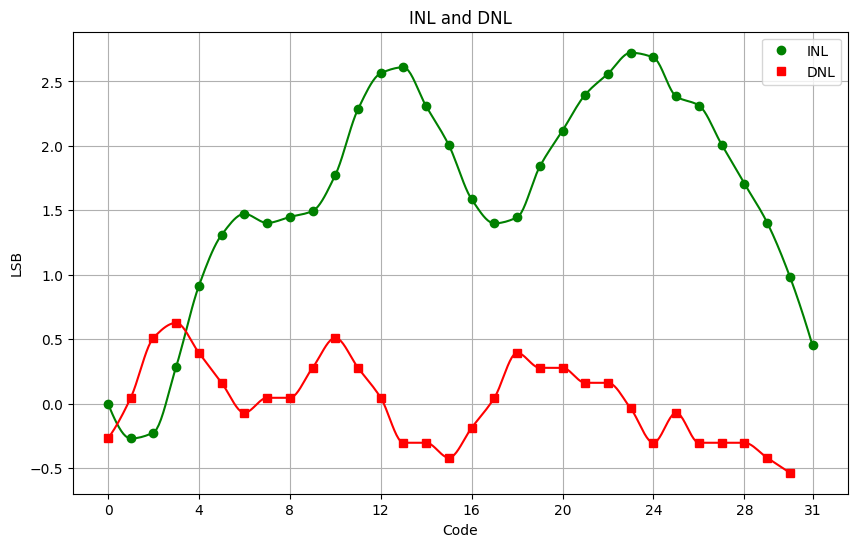

In [10]:
from scipy.interpolate import PchipInterpolator

INL_inter = PchipInterpolator(codigo,INL)
DNL_inter = PchipInterpolator(codigo[:-1],DNL)
fine_codigo_INL = np.linspace(codigo.min(),codigo.max(),10*len(codigo))
fine_codigo_DNL = np.linspace(codigo[0],codigo.max()-1,10*len(codigo))

fig_INL_DNL, ax_DNL_INL = plt.subplots(figsize=[10,6])
#ax_DNL_INL.plot(codigo,INL,'g')
ax_DNL_INL.plot(fine_codigo_INL,INL_inter(fine_codigo_INL),'g')
ax_DNL_INL.plot(codigo,INL,'go',label='INL')
ax_DNL_INL.plot(fine_codigo_DNL,DNL_inter(fine_codigo_DNL),'r')
ax_DNL_INL.plot(codigo[:-1],DNL,'rs', label='DNL')
ax_DNL_INL.set_xlabel('Code')
ax_DNL_INL.set_ylabel('LSB')
ax_DNL_INL.set_title('INL and DNL')
ax_DNL_INL.set_xticks([0,4,8,12,16,20,24,28,31])
#ax_DNL_INL.set_yticks([0,45,90,135,180,225,270,315,348.75])
ax_DNL_INL.grid()
ax_DNL_INL.legend()

print("Max. DNL: ",max(DNL))
print("Max. INL: ",max(INL))

In [11]:
pw_Q1 = PW_measv3(vout_Q1,time_Q1,stable_period,0.6,1)
print(pw_Q1)
pw_Q2 = PW_measv3(vout_Q2,time_Q2,stable_period,0.6,2)
print(pw_Q2)
pw_Q3 = PW_measv3(vout_Q3,time_Q3,stable_period,0.6,3)
print(pw_Q3)
pw_Q4 = PW_measv3(vout_Q4,time_Q4,stable_period,0.6,4)
print(pw_Q4)

pw = pw_Q1+pw_Q2+pw_Q3+pw_Q4

[700.0, 710.0, 720.0, 725.0, 715.0, 710.0, 705.0, 700.0]
[690.0, 700.0, 705.0, 700.0, 695.0, 690.0, 690.0, 685.0]
[670.0, 690.0, 695.0, 695.0, 695.0, 695.0, 690.0, 685.0]
[680.0, 690.0, 695.0, 700.0, 705.0, 705.0, 705.0, 705.0]


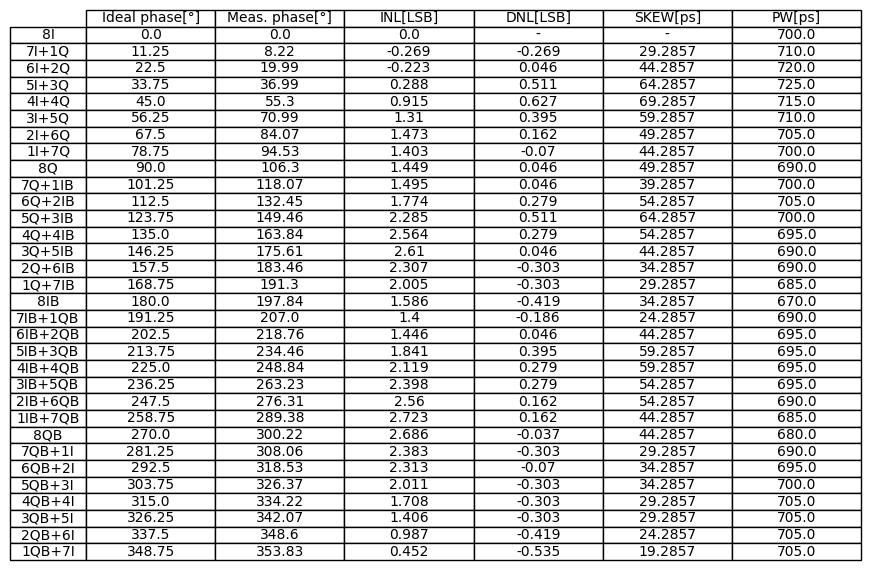

In [12]:
columns = ['Ideal phase[°]', 'Meas. phase[°]', 'INL[LSB]','DNL[LSB]','SKEW[ps]','PW[ps]']

rows = []
for i in range(0,4):
    match i:
        case 0:
            for n in range(0,8):
                if(n == 0):
                    rows.append('8I')
                else:
                    rows.append(f'{8-n}I+{n}Q')
        case 1:
            for n in range(0,8):
                if(n == 0):
                    rows.append('8Q')
                else:
                    rows.append(f'{8-n}Q+{n}IB')
        case 2:
            for n in range(0,8):
                if(n == 0):
                    rows.append('8IB')
                else:
                    rows.append(f'{8-n}IB+{n}QB')
        case 3:
            for n in range(0,8):
                if(n == 0):
                    rows.append('8QB')
                else:
                    rows.append(f'{8-n}QB+{n}I')

data = list(zip(phase_sweep_ideal,np.round(phase_sweep,decimals=2),np.round(INL,decimals=3),
            ['-']+list(np.round(DNL,decimals=3)),['-']+SKEW,pw))

fig_table , ax_table = plt.subplots(figsize=[10,6])
ax_table.axis('off')

ax_table.table(data,colLabels=columns,rowLabels=rows, loc='center', cellLoc='center', rowLoc='center')



[np.float64(0.0), np.float64(0.0), np.float64(0.3736378), np.float64(0.3736378), np.float64(0.3736378), np.float64(8.2200311), np.float64(8.2200311), np.float64(8.2200311), np.float64(6.9122989), np.float64(19.9896212), np.float64(19.9896212), np.float64(21.2973534), np.float64(19.9896212), np.float64(36.9901401), np.float64(36.9901401), np.float64(36.9901401), np.float64(36.9901401), np.float64(55.2983913), np.float64(55.2983913), np.float64(55.2983913), np.float64(55.2983913), np.float64(70.991178), np.float64(69.6834458), np.float64(69.6834458), np.float64(69.6834458), np.float64(84.0685003), np.float64(82.760768), np.float64(82.760768), np.float64(82.760768), np.float64(94.5303581), np.float64(94.5303581), np.float64(94.5303581), np.float64(102.3767514), np.float64(106.2999481), np.float64(107.6076803), np.float64(107.6076803), np.float64(110.2231448), np.float64(118.0695381), np.float64(118.0695381), np.float64(118.0695381), np.float64(121.9927348), np.float64(132.4545926), np.flo

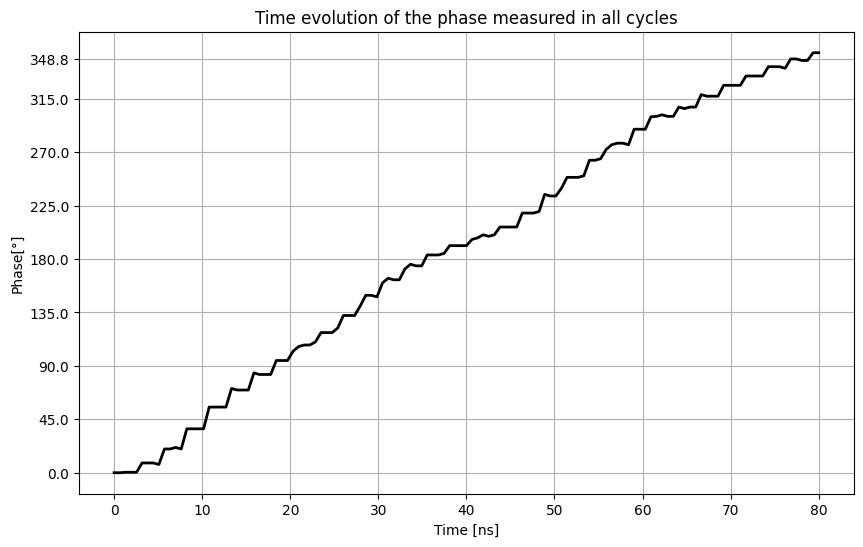

In [13]:
phase_tran = phase_tran_meas(resultados['v(vout)'][offs_time+100:],resultados['v(v8i)'][offs_time+100:],resultados['time'][offs_time+100:],0.6,offset[0],stable_period)
print(phase_tran)
time = np.linspace(0,80,len(phase_tran))


fig_phase_tran, ax_phase_tran = plt.subplots(figsize=[10,6])
ax_phase_tran.plot(time,phase_tran,'k',linewidth=2)
ax_phase_tran.set_xlabel('Time [ns]')
ax_phase_tran.set_ylabel('Phase[°]')
ax_phase_tran.set_title('Time evolution of the phase measured in all cycles')
ax_phase_tran.set_yticks([0,45,90,135,180,225,270,315,348.75])
ax_phase_tran.grid()

Average current:  6.865659837621815  mA
Max. current:  11.14496049688924  mA


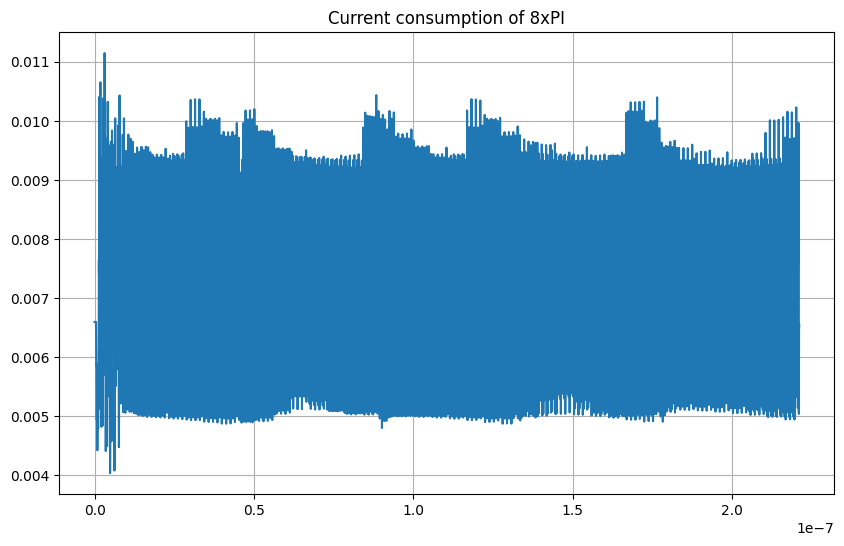

In [14]:
curr = resultados['i(vi8xpi)']
time = resultados['time']
print("Average current: ",np.mean(curr)*1e3," mA")
print("Max. current: ",np.max(curr)*1e3," mA")

fig_curr_tran, ax_curr_tran = plt.subplots(figsize=[10,6])
ax_curr_tran.set_title('Current consumption of 8xPI')
ax_curr_tran.plot(time,curr)
ax_curr_tran.grid()